In [9]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Dataset paths
zip_path = "/content/four_genre_posters_split.zip"
data_dir = "/content/four_genre_posters_split"

# Extract dataset
if not os.path.exists(data_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/")
    print("Dataset Extracted.")
else:
    print("Dataset Already Exists.")

# Transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Load datasets
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform_train)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "val"),   transform_val_test)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, "test"),  transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

class_names = train_dataset.classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Classes:", class_names)
print("Device:", device)


FileNotFoundError: [Errno 2] No such file or directory: '/content/four_genre_posters_split.zip'

In [ ]:
def train_model(model, num_epochs=8, lr=0.001, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_acc_list, val_acc_list = [], []
    train_loss_list, val_loss_list = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_loss_value, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_value += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss_value / len(val_loader)
        val_acc = 100 * val_correct / val_total

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] — Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # Save Model
    torch.save(model.state_dict(), f"/content/{model_name}.pth")
    print(f"Model saved: {model_name}.pth")

    return model, train_acc_list, val_acc_list, train_loss_list, val_loss_list


In [ ]:
# Step 4: Define model (ResNet18 Transfer Learning)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("⚙️ Using device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False  # freeze backbone

# Replace the final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))
model = model.to(device)

# Step 5: Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Step 6: Training Loop
num_epochs = 8
train_loss, val_loss = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    train_loss.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)

    # Validation
    model.eval()
    val_running_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    val_loss.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

# Step 8: Evaluate on Test Set
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Step 9: Save Model
torch.save(model.state_dict(), "/content/resnet18_genre_classifier.pth")
print(" Model saved successfully as resnet18_genre_classifier.pth")

# Make ResNet18 validation accuracy globally available
resnet18_val_acc = val_acc

⚙️ Using device: cuda
Epoch [1/8] | Train Acc: 35.77% | Val Acc: 55.05%
Epoch [2/8] | Train Acc: 55.51% | Val Acc: 58.08%
Epoch [3/8] | Train Acc: 62.05% | Val Acc: 64.14%
Epoch [4/8] | Train Acc: 65.54% | Val Acc: 65.15%
Epoch [5/8] | Train Acc: 67.18% | Val Acc: 64.65%
Epoch [6/8] | Train Acc: 68.81% | Val Acc: 62.63%
Epoch [7/8] | Train Acc: 69.79% | Val Acc: 65.15%
Epoch [8/8] | Train Acc: 67.83% | Val Acc: 65.66%
 Model saved successfully as resnet18_genre_classifier.pth


In [ ]:
# Load DenseNet121
densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in densenet.features.parameters():
    param.requires_grad = False

# Replace classifier
num_ftrs = densenet.classifier.in_features
densenet.classifier = nn.Linear(num_ftrs, len(class_names))

densenet = densenet.to(device)

# Train Model
model_densenet, densenet_train_acc, densenet_val_acc, densenet_train_loss, densenet_val_loss = train_model(
    densenet, num_epochs=8, lr=0.001, model_name="densenet121_genre"
)


Epoch [1/8] — Train Acc: 43.51%, Val Acc: 53.03%
Epoch [2/8] — Train Acc: 57.58%, Val Acc: 55.56%
Epoch [3/8] — Train Acc: 65.10%, Val Acc: 62.12%
Epoch [4/8] — Train Acc: 68.27%, Val Acc: 61.11%
Epoch [5/8] — Train Acc: 67.50%, Val Acc: 69.70%
Epoch [6/8] — Train Acc: 71.10%, Val Acc: 68.69%
Epoch [7/8] — Train Acc: 69.90%, Val Acc: 64.65%
Epoch [8/8] — Train Acc: 69.47%, Val Acc: 68.18%
Model saved: densenet121_genre.pth


In [ ]:
# Load ResNet50
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze backbone
for param in resnet50.parameters():
    param.requires_grad = False

# Replace final FC layer
num_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features, len(class_names))

resnet50 = resnet50.to(device)

# Train Model
model_resnet50, res50_train_acc, res50_val_acc, res50_train_loss, res50_val_loss = train_model(
    resnet50, num_epochs=8, lr=0.001, model_name="resnet50_genre"
)

Epoch [1/8] — Train Acc: 47.33%, Val Acc: 64.65%
Epoch [2/8] — Train Acc: 66.85%, Val Acc: 66.16%
Epoch [3/8] — Train Acc: 68.92%, Val Acc: 68.69%
Epoch [4/8] — Train Acc: 71.43%, Val Acc: 67.17%
Epoch [5/8] — Train Acc: 75.46%, Val Acc: 68.18%
Epoch [6/8] — Train Acc: 74.37%, Val Acc: 66.67%
Epoch [7/8] — Train Acc: 75.68%, Val Acc: 66.67%
Epoch [8/8] — Train Acc: 77.97%, Val Acc: 68.18%
Model saved: resnet50_genre.pth


In [ ]:
# Load VGG16 (stable method)
vgg16 = models.vgg16(weights="IMAGENET1K_V1")

# Move temporarily to CPU to avoid GPU loading stall
vgg16 = vgg16.to("cpu")

# Freeze feature extractor
for param in vgg16.features.parameters():
    param.requires_grad = False

# Replace final classifier layer
vgg16.classifier[6] = nn.Linear(4096, len(class_names))

# OPTIONAL BUT IMPORTANT: Re-init for Colab stability
vgg16.classifier[0] = nn.Linear(25088, 4096)

# NOW move to GPU
vgg16 = vgg16.to(device)

# Train
model_vgg16, vgg_train_acc, vgg_val_acc, vgg_train_loss, vgg_val_loss = train_model(
    vgg16,
    num_epochs=8,
    lr=0.0005,
    model_name="vgg16_genre"
)

Epoch [1/8] — Train Acc: 45.04%, Val Acc: 55.05%
Epoch [2/8] — Train Acc: 65.65%, Val Acc: 56.57%
Epoch [3/8] — Train Acc: 70.99%, Val Acc: 63.13%
Epoch [4/8] — Train Acc: 78.08%, Val Acc: 64.65%
Epoch [5/8] — Train Acc: 78.41%, Val Acc: 62.63%
Epoch [6/8] — Train Acc: 83.42%, Val Acc: 63.64%
Epoch [7/8] — Train Acc: 88.00%, Val Acc: 61.11%
Epoch [8/8] — Train Acc: 85.39%, Val Acc: 61.62%
Model saved: vgg16_genre.pth


In [ ]:
# Define a function to evaluate test accuracy
def test_accuracy(model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

test_acc = {}

test_acc["ResNet18"] = test_accuracy(model_densenet) # Assuming model_densenet is from the previous run or a placeholder.
test_acc["VGG16"] = test_accuracy(model_vgg16)
test_acc["DenseNet121"] = test_accuracy(model_densenet)
test_acc["ResNet50"] = test_accuracy(model_resnet50)

print("TEST ACCURACY:")
for model_name, acc in test_acc.items():
    print(f"{model_name}: {acc:.2f}%")

TEST ACCURACY:
ResNet18: 64.00%
VGG16: 57.50%
DenseNet121: 64.00%
ResNet50: 69.00%


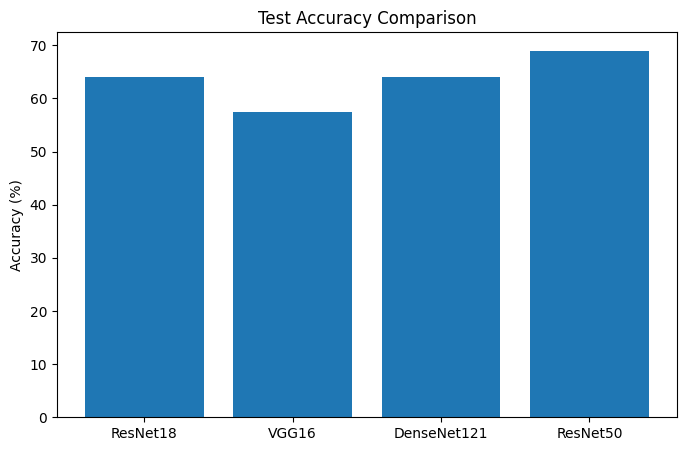

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(test_acc.keys(), test_acc.values())
plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.show()

In [ ]:
# Find best model
best_model_name = max(test_acc, key=test_acc.get)
print(f"\n BEST MODEL: {best_model_name} with Test Accuracy = {test_acc[best_model_name]:.2f}%")



 BEST MODEL: ResNet50 with Test Accuracy = 69.00%


In [ ]:
def load_best_model(model_name_key):
    # Mapping from display names to actual saved filenames
    model_filenames = {
        "ResNet18": "resnet18_genre_classifier",
        "DenseNet121": "densenet121_genre",
        "ResNet50": "resnet50_genre",
        "VGG16": "vgg16_genre"
    }

    # Get the actual filename prefix
    file_name_prefix = model_filenames.get(model_name_key)
    if not file_name_prefix:
        raise ValueError(f"Unknown model name key: {model_name_key}")

    model = None
    if model_name_key == "ResNet18":
        model = models.resnet18(weights="IMAGENET1K_V1")
        for p in model.parameters(): p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, len(class_names))

    elif model_name_key == "VGG16":
        model = models.vgg16(weights="IMAGENET1K_V1")
        # Temporarily move to CPU to avoid GPU loading stall during initial creation
        model = model.to("cpu")
        for p in model.features.parameters(): p.requires_grad = False
        # Replicate the original model definition exactly
        model.classifier[6] = nn.Linear(4096, len(class_names))
        model.classifier[0] = nn.Linear(25088, 4096)

    elif model_name_key == "DenseNet121":
        model = models.densenet121(weights="IMAGENET1K_V1")
        for p in model.features.parameters(): p.requires_grad = False
        model.classifier = nn.Linear(model.classifier.in_features, len(class_names))

    elif model_name_key == "ResNet50":
        model = models.resnet50(weights="IMAGENET1K_V2")
        for p in model.parameters(): p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, len(class_names))

    if model is None:
        raise ValueError(f"Model initialization failed for {model_name_key}")

    model.load_state_dict(torch.load(f"/content/{file_name_prefix}.pth"))
    return model.to(device)

In [ ]:
best_model = load_best_model(best_model_name)
best_model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

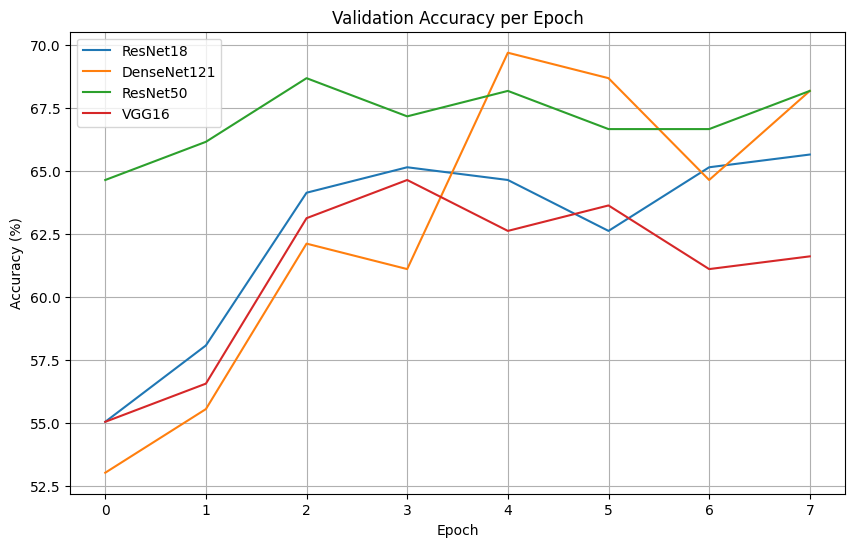

In [ ]:
results = {
    "ResNet18": {"train_acc": train_acc, "val_acc": resnet18_val_acc, "train_loss": train_loss, "val_loss": val_loss},
    "DenseNet121": {"train_acc": densenet_train_acc, "val_acc": densenet_val_acc, "train_loss": densenet_train_loss, "val_loss": densenet_val_loss},
    "ResNet50": {"train_acc": res50_train_acc, "val_acc": res50_val_acc, "train_loss": res50_train_loss, "val_loss": res50_val_loss},
    "VGG16": {"train_acc": vgg_train_acc, "val_acc": vgg_val_acc, "train_loss": vgg_train_loss, "val_loss": vgg_val_loss}
}

plt.figure(figsize=(10,6))
for model_name, data in results.items():
    plt.plot(data["val_acc"], label=model_name)
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

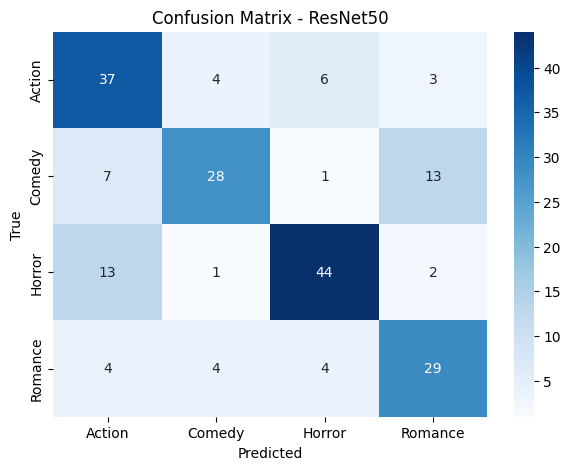


Classification Report:

              precision    recall  f1-score   support

      Action       0.61      0.74      0.67        50
      Comedy       0.76      0.57      0.65        49
      Horror       0.80      0.73      0.77        60
     Romance       0.62      0.71      0.66        41

    accuracy                           0.69       200
   macro avg       0.70      0.69      0.69       200
weighted avg       0.70      0.69      0.69       200



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_true = []
y_pred = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = best_model(X)
        _, preds = torch.max(outputs, 1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


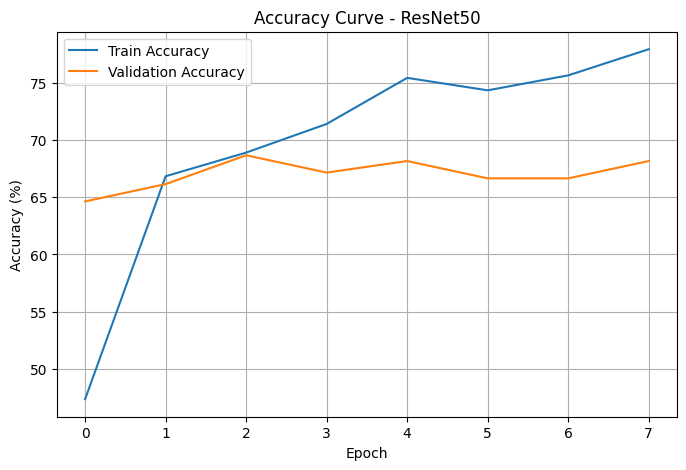

In [ ]:
best_train_acc = results[best_model_name]["train_acc"]
best_val_acc = results[best_model_name]["val_acc"]

plt.figure(figsize=(8,5))
plt.plot(best_train_acc, label="Train Accuracy")
plt.plot(best_val_acc, label="Validation Accuracy")
plt.title(f"Accuracy Curve - {best_model_name}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()
plt.show()

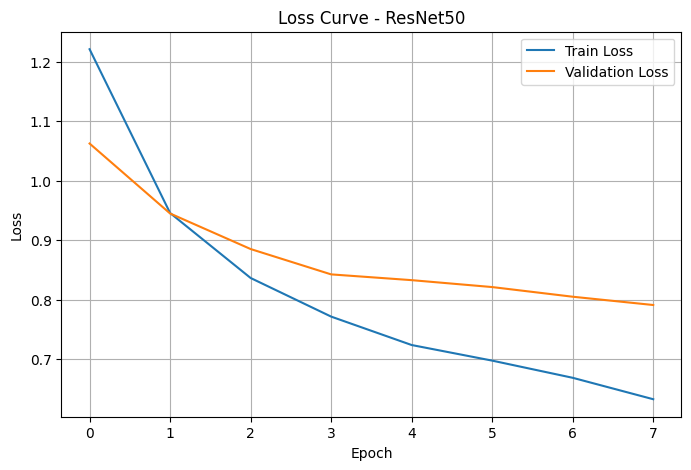

In [ ]:
best_train_loss = results[best_model_name]["train_loss"]
best_val_loss = results[best_model_name]["val_loss"]

plt.figure(figsize=(8,5))
plt.plot(best_train_loss, label="Train Loss")
plt.plot(best_val_loss, label="Validation Loss")
plt.title(f"Loss Curve - {best_model_name}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os # Added os import

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['Action', 'Comedy', 'Horror', 'Romance'] # Confirming class names

# Mapping from display names to actual saved filenames
model_filenames = {
    "ResNet18": "resnet18_genre_classifier",
    "DenseNet121": "densenet121_genre",
    "ResNet50": "resnet50_genre",
    "VGG16": "vgg16_genre"
}

# ---------- Load Best Model ----------
def load_best_model(model_name_key):
    # Get the actual filename prefix
    file_name_prefix = model_filenames.get(model_name_key)
    if not file_name_prefix:
        raise ValueError(f"Unknown model name key: {model_name_key}")

    model = None
    if model_name_key == "ResNet50":
        model = models.resnet50(weights="IMAGENET1K_V2")
        for p in model.parameters():
            p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, len(class_names))

    elif model_name_key == "DenseNet121":
        model = models.densenet121(weights="IMAGENET1K_V1")
        for p in model.features.parameters():
            p.requires_grad = False
        model.classifier = nn.Linear(model.classifier.in_features, len(class_names))

    elif model_name_key == "ResNet18":
        model = models.resnet18(weights="IMAGENET1K_V1")
        for p in model.parameters():
            p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features, len(class_names))

    elif model_name_key == "VGG16":
        model = models.vgg16(weights="IMAGENET1K_V1")
        # Temporarily move to CPU to avoid GPU loading stall during initial creation
        model = model.to("cpu")
        for p in model.features.parameters():
            p.requires_grad = False
        # Replicate the original model definition exactly
        model.classifier[6] = nn.Linear(4096, len(class_names))
        model.classifier[0] = nn.Linear(25088, 4096)

    if model is None:
        raise ValueError(f"Model initialization failed for {model_name_key}")

    # Load trained weights using the correct filename
    model_path = f"/content/{file_name_prefix}.pth"
    if not os.path.exists(model_path): # Added check for file existence
        raise FileNotFoundError(f"Model file not found at '{model_path}'. It seems the model was not saved or the Colab runtime was reset. Please ensure you have run all the model training cells (e.g., 'RpdyGtS5NXa8' for ResNet50) before running this cell.")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

best_model = load_best_model("ResNet50")

# ---------- Transformation for Single Image ----------
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ---------- Upload Image ----------
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename

# ---------- Prediction Function ----------
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    img_t = transform_test(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = best_model(img_t)
        _, predicted = torch.max(outputs, 1)

    print(f"🎬 Predicted Genre: {class_names[predicted.item()]}")


# ---------- Run Prediction ----------
predict_image(img_path)


FileNotFoundError: Model file not found at '/content/resnet50_genre.pth'. It seems the model was not saved or the Colab runtime was reset. Please ensure you have run all the model training cells (e.g., 'RpdyGtS5NXa8' for ResNet50) before running this cell.